# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [2]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

In [3]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [4]:
# mostrar las primeras 5 filas
display(df.head())

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [5]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


In [6]:
# Validar si el experimento está balanceado
print(df['landing'].value_counts())

B    20018
A    19982
Name: landing, dtype: int64


✍️ **Comentario**: 
Tras ejecutar el método `info()`, se observan los siguientes puntos clave sobre la calidad del dataset:
- **Integridad de los datos**: El dataset cuenta con 40,000 registros y todas las columnas tienen 40,000 valores no nulos. Esto indica que no hay valores ausentes en ninguna variable, lo cual es ideal para iniciar el análisis sin necesidad de imputaciones.

- **Tipos de datos**: *La mayoría de las columnas (`user_id`, `landing`, `region`, `dispositivo`, `traffic_source`, `user_type`) son de tipo **object** (categóricas), lo cual es correcto para identificadores y etiquetas.

    - La columna `converted` es de tipo **int64** (valores 0 y 1), adecuada para cálculos de proporciones.
    - La columna gasto es de tipo **float64**, correcta para representar montos monetarios.

- **Observación técnica sobre fechas**: La columna `date` se identifica actualmente como **object**. Aunque no impide el análisis estadístico del experimento A/B, se recomienda convertirla a tipo datetime si se desea analizar la evolución temporal del experimento.

- *Se realizó una validación de consistencia para ver si los grupos A y B están balanceados, de esta manera evidenciamos que el experimento se diseño adecuadamente ya que se evidencian aproximadamente 20,000 usuarios en A y ~20,000 en B. Al ser los números cercanos se puede confiar en que la asignación de usuarios fue aleatoria y equitativa.*

**Conclusión**: El dataset está limpio y listo para proceder con las pruebas estadísticas. No se requieren pasos adicionales de limpieza de valores nulos.

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [7]:
# 1. Verificar si hay user_id duplicados
duplicados = df['user_id'].duplicated().sum()

# 2. Contar el total de usuarios únicos
usuarios_unicos = df['user_id'].nunique()

print(f"Cantidad de registros duplicados: {duplicados}")
print(f"Cantidad de usuarios únicos: {usuarios_unicos}")
print(f"Total de filas en el dataset: {len(df)}")

Cantidad de registros duplicados: 0
Cantidad de usuarios únicos: 40000
Total de filas en el dataset: 40000


 **Variable `date`**  
Explorar rango de fechas

In [8]:
# Resumen estadístico
df["date"].describe()

count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [9]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [10]:
# Resumen estadístico
print("--- Resumen estadístico general (Todos los usuarios) ---")
print(df['gasto'].describe())


--- Resumen estadístico general (Todos los usuarios) ---
count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64


In [11]:
# Resumen estadístico de usuarios que se convirtieron
print("\n--- Resumen estadístico (Solo usuarios con conversión) ---")
gasto_convertidos = df[df['converted'] == 1]['gasto']
print(gasto_convertidos.describe())


--- Resumen estadístico (Solo usuarios con conversión) ---
count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64


 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [12]:
# Explorar variables categóricas y cómo se distribuyen
# Definir las variables categóricas a revisar
categoricas = ['landing', 'region', 'dispositivo', 'traffic_source', 'user_type']

print("- Conteo de categorías y distribución -")
for col in categoricas:
    print(f"\nColumna: {col}")
    print(df[col].value_counts())
    print(df[col].value_counts(normalize=True) * 100) # Ver en porcentaje %

- Conteo de categorías y distribución -

Columna: landing
B    20018
A    19982
Name: landing, dtype: int64
B    50.045
A    49.955
Name: landing, dtype: float64

Columna: region
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64
Norte        27.9150
Centro       24.0325
Sur          20.0975
Occidente    15.9950
Oriente      11.9600
Name: region, dtype: float64

Columna: dispositivo
Mobile     24829
Desktop    15171
Name: dispositivo, dtype: int64
Mobile     62.0725
Desktop    37.9275
Name: dispositivo, dtype: float64

Columna: traffic_source
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64
Organic     44.9675
Ads         29.8375
Email       15.3075
Referral     9.8875
Name: traffic_source, dtype: float64

Columna: user_type
Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64
Nuevo         65.0825
Recurrente    34.9175
Name: user_type, dtype

In [13]:
# Verificar que los dispositivos estén balanceados entre A y B
print("\n--- Distribución de Dispositivos por Versión ---")
print(pd.crosstab(df['landing'], df['dispositivo'], normalize='index') * 100)

# Verificar que las fuentes de tráfico estén balanceadas
print("\n--- Distribución de Tráfico por Versión ---")
print(pd.crosstab(df['landing'], df['traffic_source'], normalize='index') * 100)


--- Distribución de Dispositivos por Versión ---
dispositivo    Desktop     Mobile
landing                          
A            37.889100  62.110900
B            37.965831  62.034169

--- Distribución de Tráfico por Versión ---
traffic_source        Ads      Email    Organic   Referral
landing                                                   
A               29.931939  15.448904  45.000500   9.618657
B               29.743231  15.166350  44.934559  10.155860


✍️ **Comentario**:
**Hallazgos de la Revisión de Calidad de Datos**
Tras ejecutar las pruebas de validación en la sección 1.2, se presentan los siguientes hallazgos:
- **Integridad de Usuarios**: La columna `user_id` contiene 40,000 valores únicos, lo que coincide con el total de filas. Esto garantiza que no hay registros duplicados y que cada usuario es una unidad de análisis independiente.
- **Balance del Experimento**: Los grupos están distribuidos de forma equitativa: **Versión B (20,018)** y **Versión A (19,982)**. Esta diferencia no es significativa y confirma un correcto proceso de aleatorización.
- **Rango Temporal**: El experimento se realizó en un periodo de 30 días, iniciando el 1 de enero de 2026 y finalizando el 31 de enero de 2026.
- **Validación de Gasto**: * Se confirmó que la columna gasto tiene *valores de 0 para los usuarios que no convirtieron*.
    - Para los usuarios que sí convirtieron, el **gasto promedio es de 33.15, con un valor máximo de 63.15**.
    - No se detectaron valores negativos ni inconsistencias lógicas (como gastos sin conversión).
- **Consistencia Categórica**: Las variables de región, dispositivo y fuente de tráfico presentan las categorías esperadas (Norte, Sur, Mobile, Desktop, Ads, etc.) sin errores de escritura ni valores nulos.

**Conclusión**: Todas las columnas tienen los valores esperados y el dataset es consistente. No se requiere limpieza adicional, por lo que se procede con el análisis estadístico de las hipótesis de negocio.

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [18]:

# Gasto por versión (solo usuarios que convirtieron)
gasto_A = df[(df['landing'] == 'A') & (df['converted'] == 1)]['gasto']
gasto_B = df[(df['landing'] == 'B') & (df['converted'] == 1)]['gasto']

# Verificar cantidad de datos que tiene cada grupo (cuántas ventas hubo en cada uno)
print(f"Ventas en versión A: {len(gasto_A)}")
print(f"Ventas en versión B: {len(gasto_B)}")


Ventas en versión A: 2512
Ventas en versión B: 3194


### Prueba ...
**Hipótesis:**
- **Hipótesis nula (H₀):** No existe una diferencia significativa entre el gasto promedio de la versión A y la versión B ($μA​=μB​$).
- **Hipótesis alternativa (H₁):** Existe una diferencia significativa entre el gasto promedio de la versión A y la versión B ($μA​\neq μB​$).
- **Nivel de significancia (α):** 0.05 (5%).

In [15]:
# ttest_ind compara las medias de dos grupos independientes
t_stat, p_val_gasto = stats.ttest_ind(gasto_A, gasto_B, equal_var=False)

# Visualizar resultados
print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p: {p_val_gasto:.4f}")

Estadístico t: -9.4810
Valor p: 0.0000


In [16]:
# Comparación con el nivel de significancia (alpha = 0.05)
if p_val_gasto < 0.05:
    print("\nResultado: Hay una diferencia estadísticamente significativa.")
else:
    print("\nResultado: No hay evidencia suficiente para afirmar una diferencia.")


Resultado: Hay una diferencia estadísticamente significativa.



### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula (H0​).

**Interpretación de negocio:** Los resultados muestran que existe una diferencia estadísticamente significativa en el gasto promedio entre ambas versiones. El valor p de 0.0000 (que es menor al nivel de significancia de 0.05) nos indica que la probabilidad de que esta diferencia se deba al azar es prácticamente nula. Por lo que  confirmamos que existe una diferencia estadísticamente significativa en el gasto.

El estadístico t negativo (-9.4810) indica que la media del **grupo B** es significativamente mayor que la del **grupo A**. Por lo tanto, la página B genera un gasto promedio por usuario mayor que la página A. Asimismo, esto significa que la versión B no solo atrae a más compradores (como vimos en el conteo de ventas), sino que además logra que cada comprador gaste, en promedio, más dinero. Por lo tanto, desde el punto de vista del valor económico por transacción, la Versión B es superior.



## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe una diferencia significativa entre la tasa de conversión de la página A y la página B ($pA​=pB​$).
- **Hipótesis alternativa (H₁):** Existe una diferencia significativa entre la tasa de conversión de la página A y la página B ($pA​\neq pB​$).
- **Nivel de significancia (α):** 0.05 (5%).

In [19]:
# Número de usuarios convertidos por página (éxitos)
conversions = df.groupby('landing')['converted'].sum()

# Total de usuarios por página (intentos/muestra)
total_users = df.groupby('landing')['converted'].count()

print("Usuarios convertidos por página:\n", conversions)
print("\nTotal de usuarios por página:\n", total_users)

Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: converted, dtype: int64


In [22]:

# Aplicar prueba
from statsmodels.stats.proportion import proportions_ztest 

# Definir los éxitos (convertidos) y las observaciones (totales)
count = [conversions['B'], conversions['A']]
nobs = [total_users['B'], total_users['A']]

# Ejecutar la prueba Z
z_stat, p_value_conv = proportions_ztest(count, nobs)

# Visualizar resultados
print(f"Estadístico Z: {z_stat:.4f}")
print(f"Valor p: {p_value_conv:.4f}")


Estadístico Z: 9.6774
Valor p: 0.0000


In [24]:
# Evaluación de la Hipótesis
alpha = 0.05
if p_value_conv < alpha:
    print("\nResultado: Hay una diferencia significativa en la tasa de conversión.")
    if z_stat > 0:
        print("La versión B tiene una tasa de conversión significativamente mayor que la A.")
    else:
        print("La versión A tiene una tasa de conversión significativamente mayor que la B.")
else:
    print("\nResultado: No hay evidencia suficiente para afirmar una diferencia significativa entre ambas versiones.")



Resultado: Hay una diferencia significativa en la tasa de conversión.
La versión B tiene una tasa de conversión significativamente mayor que la A.


### 📝 Conclusión e interpretación

**Decisión:** Se rechaza la hipótesis nula (H0​).

**Interpretación de negocio:** El análisis estadístico confirma que la **Versión B** es significativamente más efectiva que la **Versión A** para generar conversiones.
- Evidencia: El valor p de 0.0000 (menor al nivel de significancia de 0.05) indica que la probabilidad de que esta mejora sea fruto del azar es poca.
- Resultados: La página B logró 3,194 conversiones frente a las 2,512 de la página A. Esto representa un aumento en la cantidad de usuarios que deciden realizar una compra al interactuar con el nuevo diseño.
- Impacto: El estadístico Z positivo (9.6774) ratifica que la tasa de conversión de la Versión B es superior. Al combinar este hallazgo con el resultado del Paso 2 (donde vimos que B también genera un mayor gasto promedio), podemos concluir que la página B es la ganadora del experimento, superando a la versión actual. 

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe asociación entre la fuente de tráfico y la conversión. La conversión es independiente del canal de origen.
- **Hipótesis alternativa (H₁):** Existe una asociación significativa entre la fuente de tráfico y la conversión. El canal de origen influye en la probabilidad de compra.
- **Nivel de significancia (α):** 0.05 (5%).

In [26]:
# Aplicar prueba
from scipy.stats import chi2_contingency

# 1. Crear la tabla de contingencia
contingency_traffic = pd.crosstab(df['traffic_source'], df['converted'])

print("Tabla de contingencia (Fuente de tráfico vs Conversión):")
display(contingency_traffic)

# 2. Aplicar la prueba Chi-cuadrado
chi2, p_val_traffic, dof, expected = chi2_contingency(contingency_traffic)

Tabla de contingencia (Fuente de tráfico vs Conversión):


converted,0,1
traffic_source,,
Ads,10176,1759
Email,5205,918
Organic,15507,2480
Referral,3406,549


In [27]:
# Visualizar resultados
print(f"\nEstadístico Chi-cuadrado: {chi2:.4f}")
print(f"Valor p: {p_val_traffic:.4f}")

# Evaluación
if p_val_traffic < 0.05:
    print("\nResultado: Existe una asociación significativa entre la fuente de tráfico y la conversión.")
else:
    print("\nResultado: No hay evidencia suficiente para afirmar una asociación (son independientes).")


Estadístico Chi-cuadrado: 8.6621
Valor p: 0.0341

Resultado: Existe una asociación significativa entre la fuente de tráfico y la conversión.


### 📝 Conclusión e interpretación

**Decisión:** Se rechaza la hipótesis nula (H0​).

**Interpretación de negocio:** El análisis estadístico a través de la prueba Chi-cuadrado arroja un valor p de 0.0341, el cual es menor al nivel de significancia de 0.05. Esto confirma que existe una asociación significativa entre la fuente de tráfico y la conversión; es decir, la probabilidad de que un usuario compre depende del canal por el cual llegó a la página.

Al observar los datos:
- El tráfico *organic* es el que más usuarios atrae (15,507) y el que más conversiones totales genera (2,480). Sin embargo, esto no significa necesariamente que sea el más eficiente, sino el más masivo.
- Si observamos las proporciones, canales como *Ads* y *Email* muestran una relación muy sólida entre quienes entran y quienes compran.
- Dado que la conversión no es uniforme entre canales, el equipo de marketing debe entender que no todos los tráficos "valen lo mismo". Existe un sesgo de comportamiento: por ejemplo, un usuario que llega por un *Referral* o un *Ads* podría tener una intención de compra distinta a uno que llega de forma *organic*

**Recomendación:** Se sugiere realizar un análisis de retorno de inversión (ROI) por canal, ya que ahora sabemos estadísticamente que la fuente de origen es un factor determinante en el éxito de la conversión.


## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe asociación entre el tipo de usuario (Nuevo o Recurrente) y la conversión. La conversión es independiente de si el usuario ya conocía el sitio. 
- **Hipótesis alternativa (H₁):** Existe una asociación significativa entre el tipo de usuario y la conversión. El perfil del usuario influye en su probabilidad de compra.
- **Nivel de significancia (α):** 0.05 (5%).

In [31]:
# Aplicar prueba
from scipy.stats import chi2_contingency

# 1. Crear la tabla de contingencia
contingency_user = pd.crosstab(df['user_type'], df['converted'])

print("Tabla de contingencia (Tipo de usuario vs Conversión):")
display(contingency_user)

# 2. Aplicar la prueba Chi-cuadrado
chi2_user, p_val_user, dof_user, expected_user = chi2_contingency(contingency_user)

Tabla de contingencia (Tipo de usuario vs Conversión):


converted,0,1
user_type,,
Nuevo,22295,3738
Recurrente,11999,1968


In [29]:
# Visualizar resultados
print(f"\nEstadístico Chi-cuadrado: {chi2_user:.4f}")
print(f"Valor p: {p_val_user:.4f}")

# Evaluación automática
if p_val_user < 0.05:
    print("\nResultado: Existe una asociación significativa entre el tipo de usuario y la conversión.")
else:
    print("\nResultado: No hay evidencia suficiente para afirmar una asociación (son independientes).")


Estadístico Chi-cuadrado: 0.5135
Valor p: 0.4736

Resultado: No hay evidencia suficiente para afirmar una asociación (son independientes).


### 📝 Conclusión e interpretación

**Decisión:**  No se rechaza la hipótesis nula (H0​).

**Interpretación de negocio:** El análisis estadístico a través de la prueba Chi-cuadrado arroja un valor p de 0.4736, el cual es significativamente superior al nivel de significancia de 0.05. Esto indica que no existe una asociación significativa entre el tipo de usuario (Nuevo o Recurrente) y la conversión.
- Análisis de los datos: Al observar la tabla de contingencia, vemos que tanto los usuarios nuevos como los recurrentes mantienen una proporción de conversión muy similar (alrededor del 14%).
- Significado estratégico: Esto nos dice que la efectividad de la página de inicio no depende de la familiaridad previa del usuario con el sitio. La landing page funciona de manera equitativa para atraer a alguien que entra por primera vez como para alguien que ya nos conoce.


**Conclusión final:** El factor que realmente está moviendo la aguja en este experimento es el diseño de la página (A vs B) y, en menor medida, la fuente de tráfico, pero no el perfil de lealtad del usuario.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

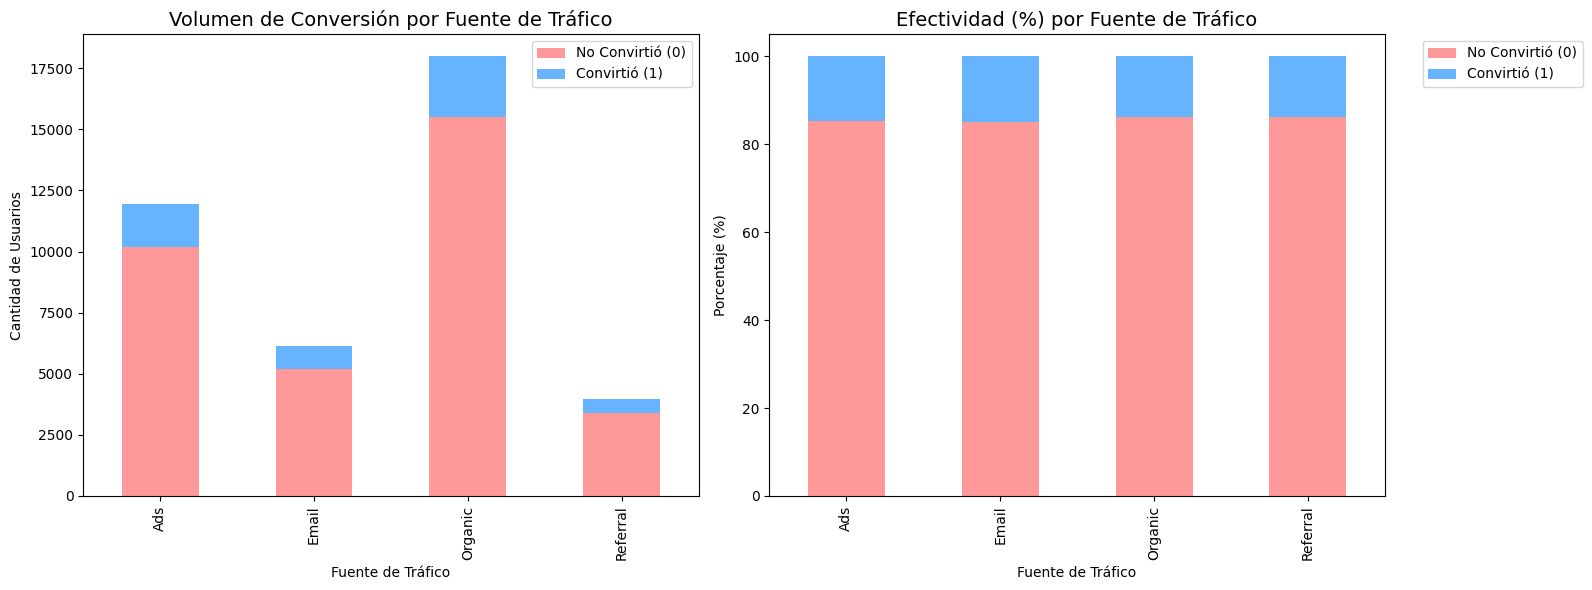

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparar los datos
traffic_conv = pd.crosstab(df['traffic_source'], df['converted'])
traffic_conv_pct = pd.crosstab(df['traffic_source'], df['converted'], normalize='index') * 100

# 2. Crear la figura con dos subgráficos
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de Barras: Cantidad Absoluta
traffic_conv.plot(kind='bar', stacked=True, color=['#ff9999','#66b3ff'], ax=ax[0])
ax[0].set_title('Volumen de Conversión por Fuente de Tráfico', fontsize=14)
ax[0].set_ylabel('Cantidad de Usuarios')
ax[0].set_xlabel('Fuente de Tráfico')
ax[0].legend(['No Convirtió (0)', 'Convirtió (1)'])

# Gráfico de Barras: Proporción (Efectividad Relativa)
traffic_conv_pct.plot(kind='bar', stacked=True, color=['#ff9999','#66b3ff'], ax=ax[1])
ax[1].set_title('Efectividad (%) por Fuente de Tráfico', fontsize=14)
ax[1].set_ylabel('Porcentaje (%)')
ax[1].set_xlabel('Fuente de Tráfico')
ax[1].legend(['No Convirtió (0)', 'Convirtió (1)'], bbox_to_anchor=(1.05, 1))

# Ajustar diseño
plt.tight_layout()
plt.show()

✍️ **Comentario**: 
**Análisis de la Fuente de Tráfico vs. Conversión**
Las visualizaciones permiten contrastar el volumen total de usuarios frente a la efectividad real de cada canal de adquisición:
- **Volumen por fuente** (Gráfico de Barras Absolutas): Se observa que el tráfico *Organic* es el principal motor de entrada de usuarios y, por ende, el que aporta el mayor número bruto de conversiones. Sin embargo, el volumen masivo puede ocultar diferencias en la calidad del tráfico.
- **Efectividad relativa** (Gráfico de Barras Porcentuales): Al normalizar los datos, confirmamos visualmente el resultado de la prueba Chi-cuadrado. No todas las fuentes convierten igual. Canales como *Ads* y *Email* muestran una proporción de conversión ligeramente superior en comparación con el tráfico *Referral*.

**Conclusión Visual:** Aunque las diferencias en los porcentajes parecen sutiles a simple vista, son estadísticamente significativas. Esto sugiere que los usuarios que llegan a través de campañas pagas o dirigidas (Ads/Email) tienen una intención de compra más definida o responden mejor a la landing page que aquellos que llegan de manera orgánica o referida.

### Relación entre el tipo de usuario y la conversión

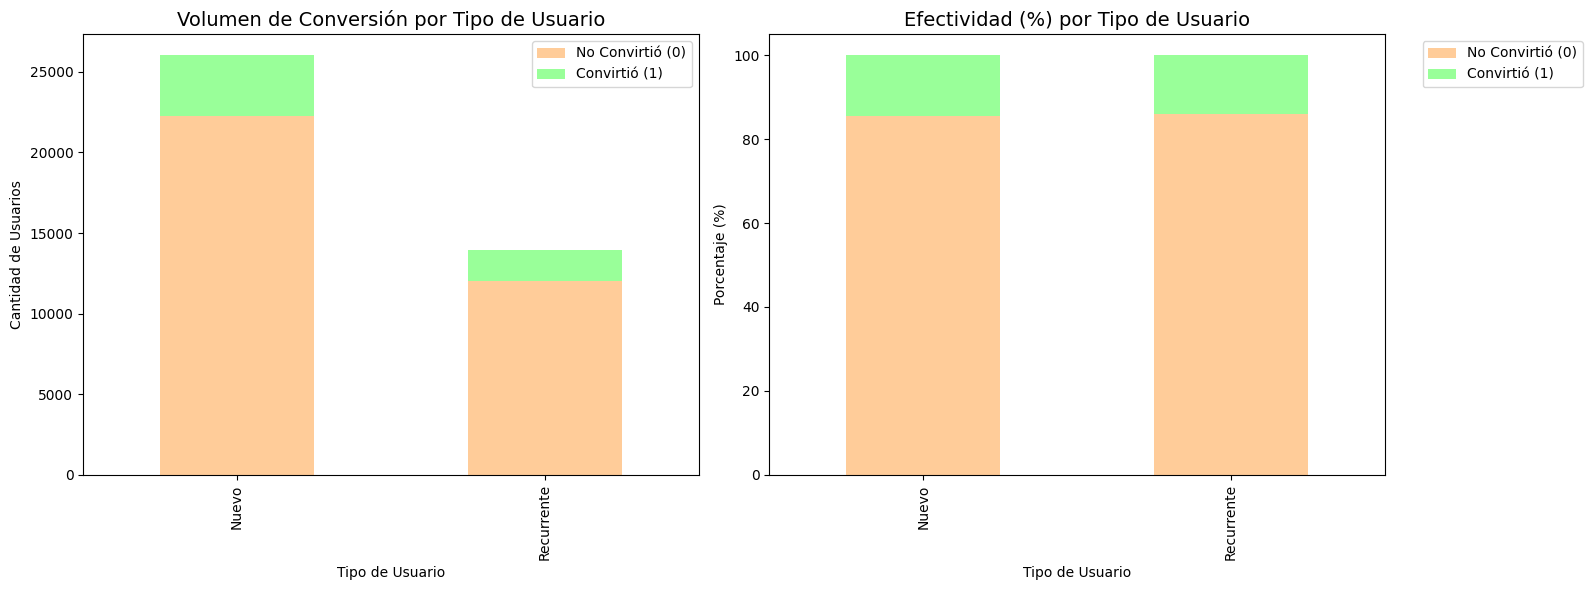

In [33]:
# 1. Preparar los datos
user_type_conv = pd.crosstab(df['user_type'], df['converted'])
user_type_conv_pct = pd.crosstab(df['user_type'], df['converted'], normalize='index') * 100

# 2. Crear la figura con dos subgráficos
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de Barras: Cantidad Absoluta
user_type_conv.plot(kind='bar', stacked=True, color=['#ffcc99','#99ff99'], ax=ax[0])
ax[0].set_title('Volumen de Conversión por Tipo de Usuario', fontsize=14)
ax[0].set_ylabel('Cantidad de Usuarios')
ax[0].set_xlabel('Tipo de Usuario')
ax[0].legend(['No Convirtió (0)', 'Convirtió (1)'])

# Gráfico de Barras: Proporción (Efectividad Relativa)
user_type_conv_pct.plot(kind='bar', stacked=True, color=['#ffcc99','#99ff99'], ax=ax[1])
ax[1].set_title('Efectividad (%) por Tipo de Usuario', fontsize=14)
ax[1].set_ylabel('Porcentaje (%)')
ax[1].set_xlabel('Tipo de Usuario')
ax[1].legend(['No Convirtió (0)', 'Convirtió (1)'], bbox_to_anchor=(1.05, 1))

# Ajustar diseño
plt.tight_layout()
plt.show()

✍️ **Comentario**: 
**Análisis del Tipo de *Usuario vs. Conversión***
Las visualizaciones permiten contrastar el comportamiento de los usuarios según su nivel de lealtad o conocimiento previo del sitio:
- **Distribución de volumen** (Gráfico izquierdo): Se observa una predominancia clara de *Usuarios Nuevos* en comparación con los *Recurrentes*. Esto sugiere que el sitio tiene una alta capacidad de atracción de tráfico fresco, el cual representa la mayor parte de la carga operativa y de las conversiones totales en términos absolutos.
- **Comparativa de efectividad** (Gráfico derecho): Al normalizar los datos por porcentaje, las barras de conversión (color verde) muestran una altura prácticamente idéntica. Ambos segmentos presentan una tasa de éxito muy similar, lo que visualmente explica por qué la prueba estadística arrojó un valor p tan alto (0.4736).

**Hallazgo clave:** No existe una ventaja competitiva en términos de conversión por el hecho de que un usuario sea recurrente. La página de inicio es igualmente efectiva para convencer a un usuario que interactúa por primera vez como a uno que ya conoce la marca. **Esto indica que el diseño actual (especialmente la Versión B) tiene un impacto universal que no depende de la familiaridad previa del cliente con la plataforma.**

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?

---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- **Observación 1:** La Versión B superó significativamente a la Versión A en el ticket promedio de venta.
- **Observación 2:** El estadístico t de -9.48 y un valor p de 0.0000 confirman que esta diferencia no es casualidad.
- **Interpretación:** Los usuarios no solo prefieren la interfaz de la página B, sino que su diseño o disposición de productos incentiva un mayor desembolso económico por transacción.
  
<br>

**Tasa de conversión:** 
- **Observacion 1:** Los usuarios no solo prefieren la interfaz de la página B, sino que su diseño o disposición de productos incentiva un mayor desembolso económico por transacción.
- **Observacion 2:** La prueba Z arrojó un estadístico de 9.67, validando una mejora drástica en la capacidad de persuasión de la nueva página.
- **Interpretación:** La Versión B es más eficiente en el embudo de ventas, logrando "convencer" a un mayor porcentaje de visitantes para finalizar la compra.

---

#### 📊 **Segmentación por fuente de tráfico**
- **Observacion:** Existe una asociación significativa (p=0.0341) entre el origen del tráfico y la conversión, destacando que canales como *Ads* y *Email* presentan una efectividad superior.
- **Interpretación:** No todo el tráfico tiene la misma calidad. Los esfuerzos de marketing pagados y dirigidos están atrayendo usuarios con una intención de compra más alta que el tráfico orgánico o de referidos.
 
 ---

#### 📊 **Segmentación por tipo de usuario**
- **Observacion:** No se encontró diferencia significativa (p=0.4736) entre usuarios nuevos y recurrentes.
- **Interpretación:** El rendimiento de la plataforma es consistente. La decisión de compra en este experimento depende del diseño de la página y el canal de origen, pero no de si el usuario ya conocía el sitio previamente.

---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:** 
- **Implementación inmediata de la Versión B:** Dado que la Versión B es superior tanto en volumen de ventas como en monto gastado, se recomienda sustituir definitivamente la versión A. Esta acción garantiza un incremento directo en los ingresos totales.
-  **Optimización de presupuesto en canales de Pago:** Aumentar la inversión en *Ads* y *Email* Marketing, ya que estadísticamente han demostrado ser los canales con mayor tasa de éxito.
-  **Estrategia unificada:** No es necesario crear campañas diferenciadas para usuarios nuevos y recurrentes en este momento, ya que ambos responden de igual manera. Es mejor enfocar los recursos creativos en potenciar los elementos visuales de la Versión B que impulsan el ticket promedio.